In [35]:
import os
from langchain.tools import tool
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv

load_dotenv()

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

In [36]:
model = init_chat_model(
    "gemini-2.5-flash-lite",
    temperature=0,
    model_provider="google_genai",
    api_key=GEMINI_API_KEY
)

In [37]:
model

ChatGoogleGenerativeAI(profile={'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-2.5-flash-lite', temperature=0.0, client=<google.genai.client.Client object at 0x72a8336ee900>, default_metadata=(), model_kwargs={})

In [38]:
@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b

In [39]:
tools = [multiply, add, divide]
tools_by_name = {tool.name: tool for tool in tools}

tools_by_name

{'multiply': StructuredTool(name='multiply', description='Multiply `a` and `b`.\n\n    Args:\n        a: First int\n        b: Second int', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x72a832875d00>),
 'add': StructuredTool(name='add', description='Adds `a` and `b`.\n\n    Args:\n        a: First int\n        b: Second int', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x72a832875ee0>),
 'divide': StructuredTool(name='divide', description='Divide `a` and `b`.\n\n    Args:\n        a: First int\n        b: Second int', args_schema=<class 'langchain_core.utils.pydantic.divide'>, func=<function divide at 0x72a832875da0>)}

In [40]:
model_with_tools = model.bind_tools(tools)

In [41]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
import operator

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls: int

In [42]:
from langchain.messages import SystemMessage

def llm_call(state: dict):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            model_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )
                ]
                + state["messages"]
            )
        ],
        "llm_calls": state.get('llm_calls', 0) + 1
    }

In [43]:
from langchain.messages import ToolMessage


def tool_node(state: dict):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call['name']]
        observation = tool.invoke(tool_call['args'])
        result.append(ToolMessage(
            content=observation, tool_call_id=tool_call["id"]
        ))
    return { "messages": result }

In [44]:
from typing import Literal
from langgraph.graph import StateGraph, START, END

def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]

    if last_message.tool_calls:
        return "tool_node"

    return END    

In [53]:
# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)

agent_builder.add_edge("tool_node", END)
# agent_builder.add_edge(START, "llm_call")
# agent_builder.add_conditional_edges(
#     "llm_call",
#     should_continue,
#     ["tool_node", END]
# )
# agent_builder.add_edge("tool_node", "llm_call")


agent = agent_builder.compile()

In [47]:
agent_builder

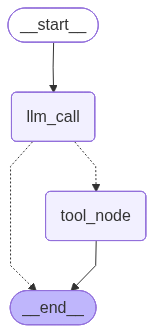

In [54]:
agent

In [55]:
from langchain.messages import HumanMessage
messages = [HumanMessage(content="Add 3 and 4.")]
messages = agent.invoke({"messages": messages})

In [56]:
messages

{'messages': [HumanMessage(content='Add 3 and 4.', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'add', 'arguments': '{"a": 3, "b": 4}'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d8659-e79f-7d50-b31b-71411331546f-0', tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 4}, 'id': 'eb18ab64-c3c0-4ea4-bcb7-39d080a97a03', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 218, 'output_tokens': 18, 'total_tokens': 236, 'input_token_details': {'cache_read': 0}}),
  ToolMessage(content='7', tool_call_id='eb18ab64-c3c0-4ea4-bcb7-39d080a97a03')],
 'llm_calls': 1}

In [57]:
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (eb18ab64-c3c0-4ea4-bcb7-39d080a97a03)
 Call ID: eb18ab64-c3c0-4ea4-bcb7-39d080a97a03
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
